In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(
    "../data/processed/processed_walmart_sales.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)
df.head()

(6435, 15)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter,Day,DayOfWeek,WeekendFlag
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1,5,4,0
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1,12,4,0
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1,19,4,0
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1,26,4,0
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1,5,4,0


Outlier Detection

In [2]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Quarter', 'Day',
       'DayOfWeek', 'WeekendFlag'],
      dtype='object')

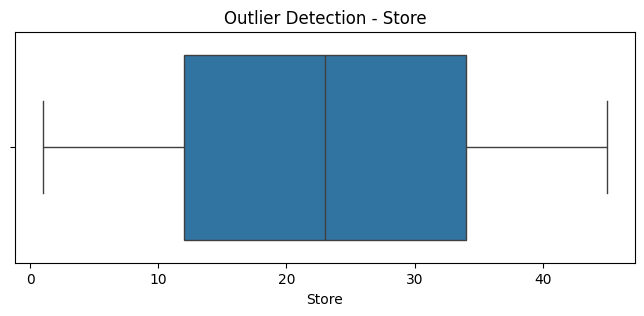

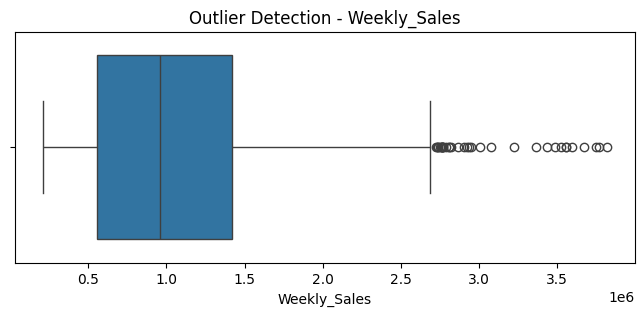

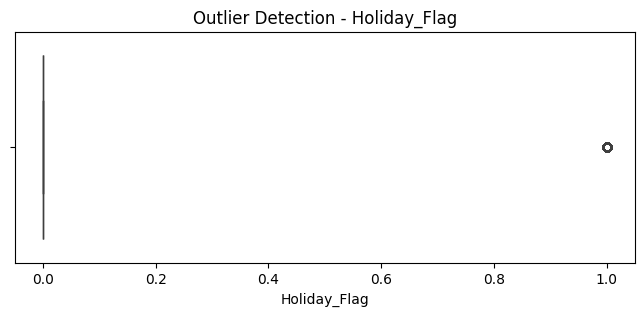

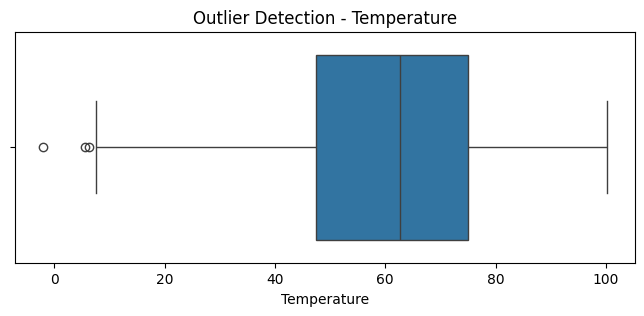

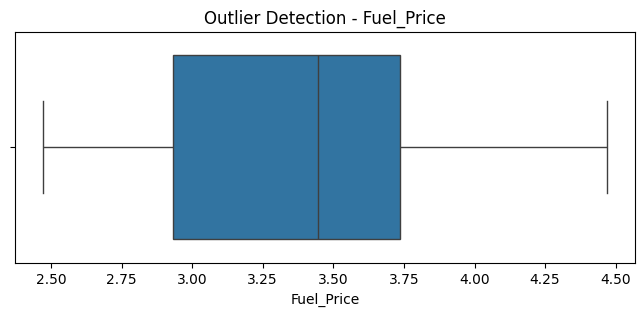

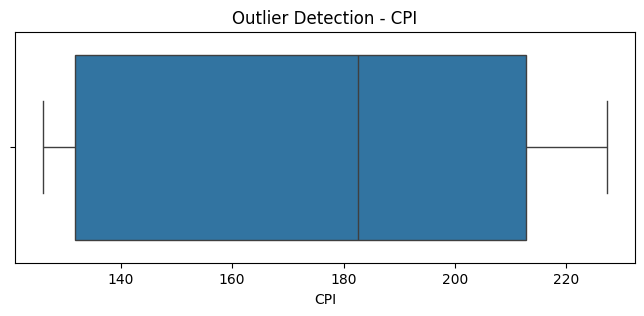

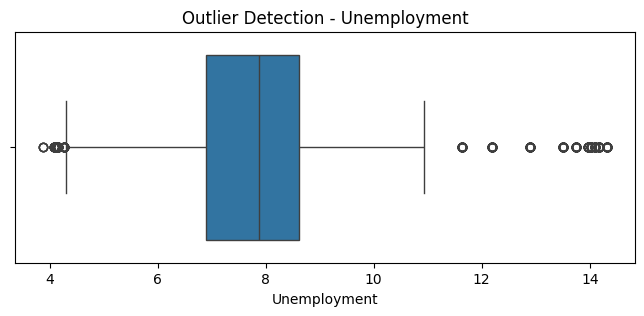

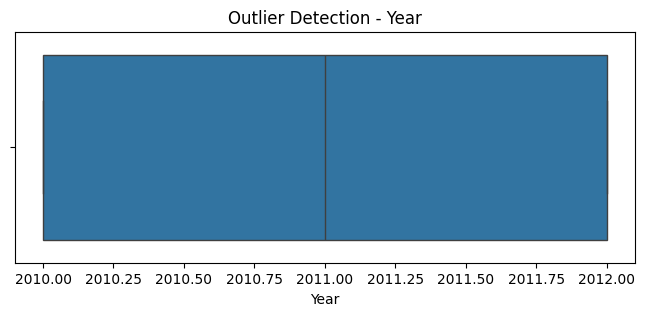

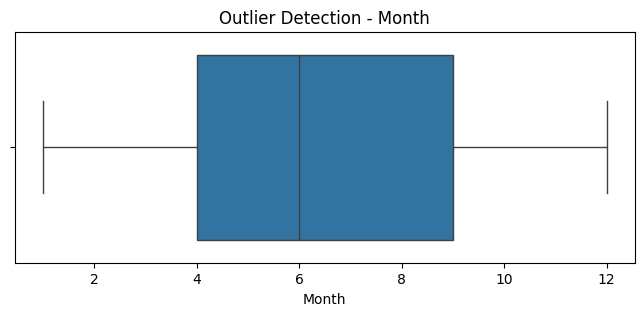

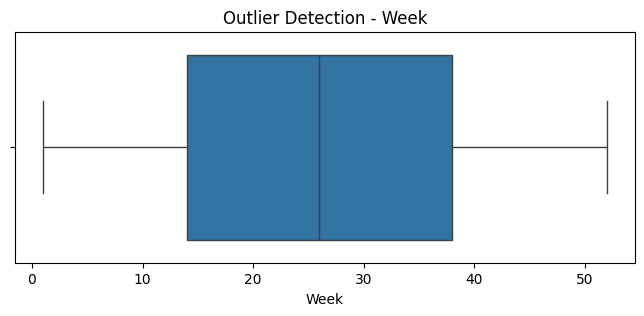

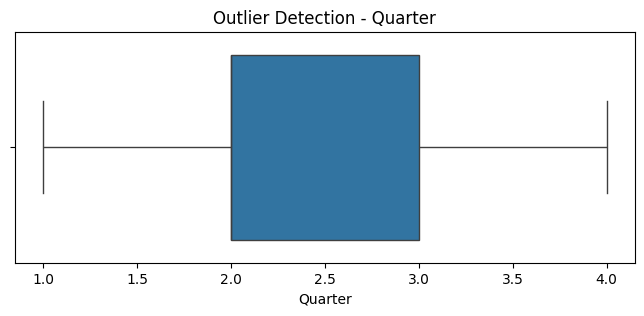

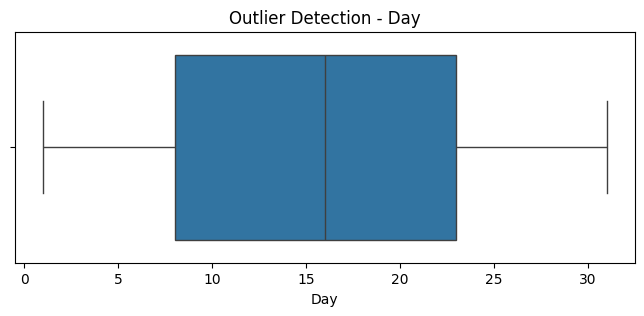

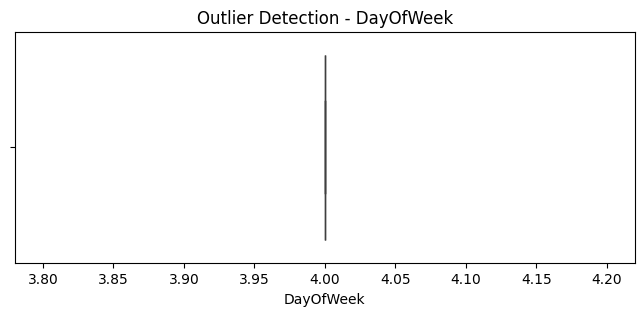

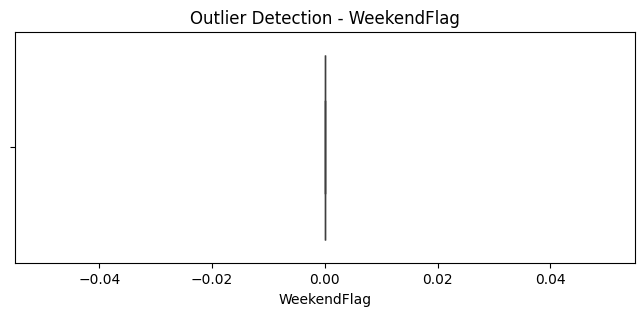

In [3]:
for col in numeric_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(f"Outlier Detection - {col}")

    plt.show()

Daily Sales Trend

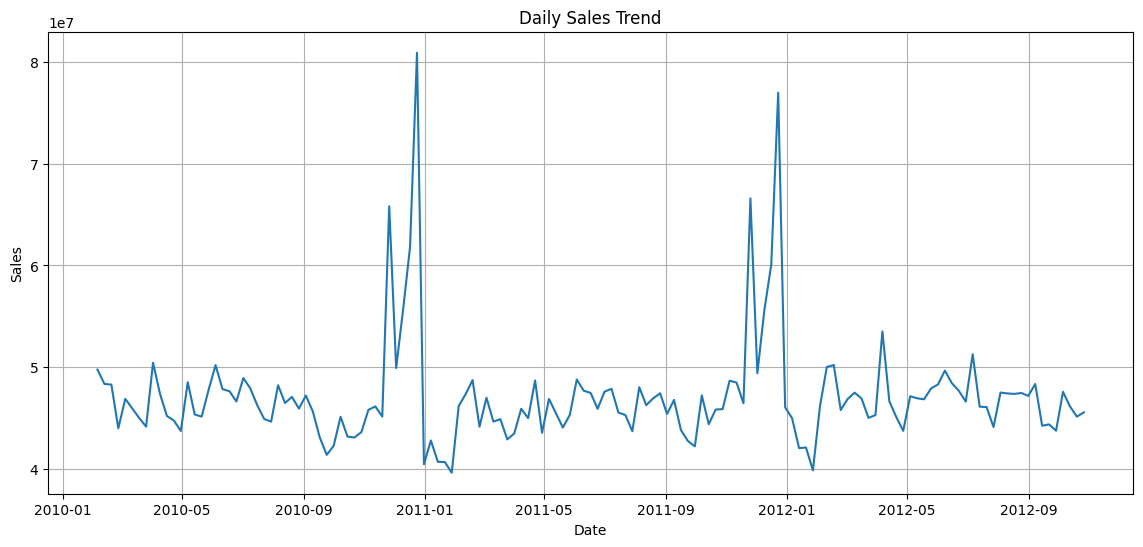

In [4]:
daily_sales = df.groupby(
    "Date"
)["Weekly_Sales"].sum()

plt.figure(figsize=(14,6))

plt.plot(
    daily_sales.index,
    daily_sales.values
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

Weekly Sales Trend

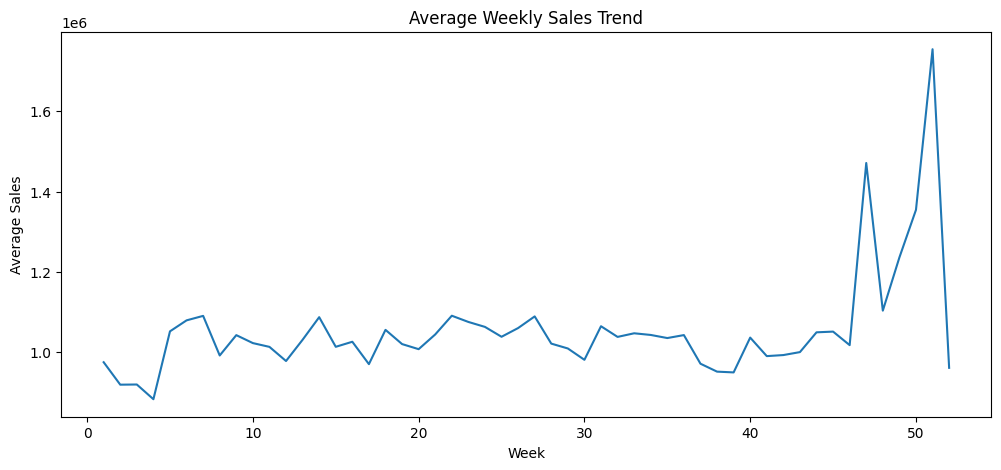

In [6]:
weekly_sales = df.groupby(
    "Week"
)["Weekly_Sales"].mean()

plt.figure(figsize=(12,5))

sns.lineplot(
    x=weekly_sales.index,
    y=weekly_sales.values
)

plt.title("Average Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Average Sales")

plt.show()

Monthly Sales Trend

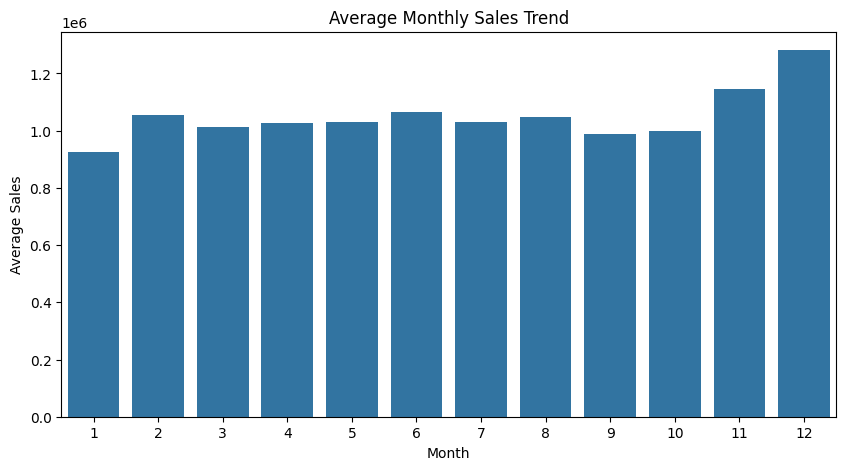

In [7]:
monthly_sales = df.groupby(
    "Month"
)["Weekly_Sales"].mean()

plt.figure(figsize=(10,5))

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title("Average Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

Store-wise Sales Comparison

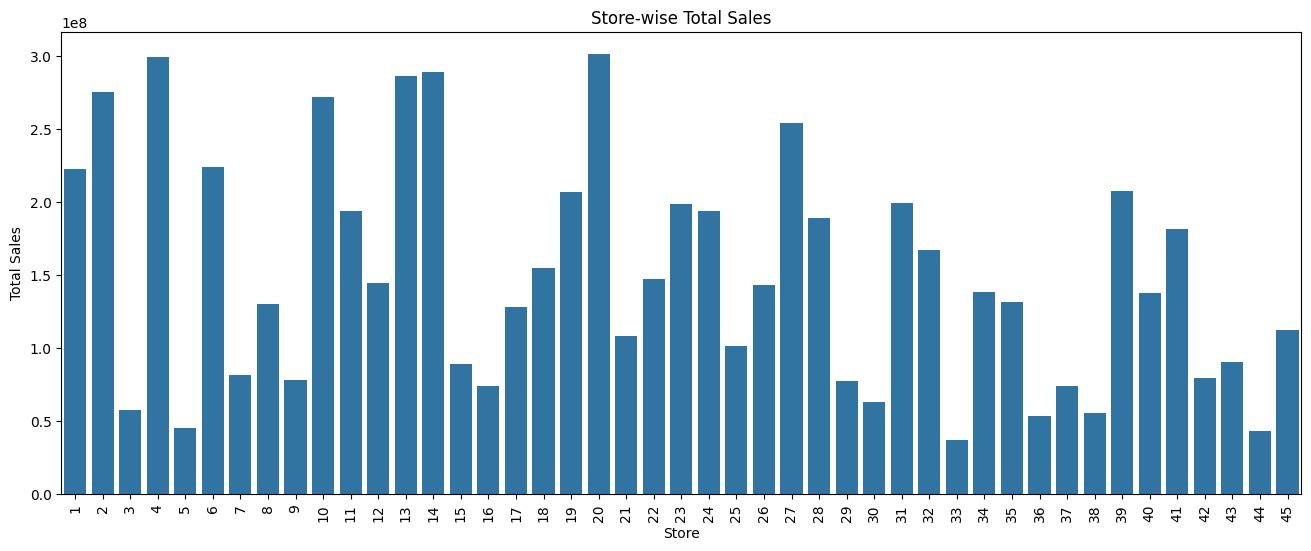

In [8]:
store_sales = df.groupby(
    "Store"
)["Weekly_Sales"].sum()

plt.figure(figsize=(16,6))

sns.barplot(
    x=store_sales.index,
    y=store_sales.values
)

plt.title("Store-wise Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.show()

In [9]:
holiday_sales = df.groupby(
    "Holiday_Flag"
)["Weekly_Sales"].mean()

holiday_sales

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

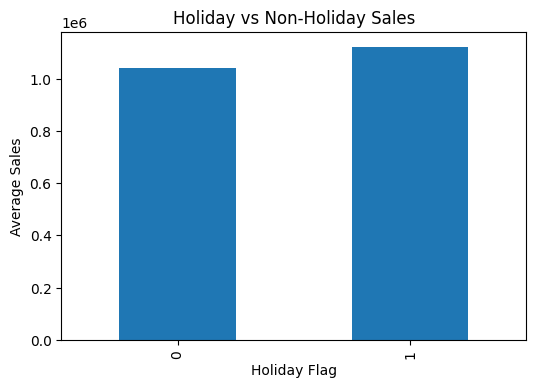

In [10]:
holiday_sales.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Sales")

plt.show()

Correlation Heatmap

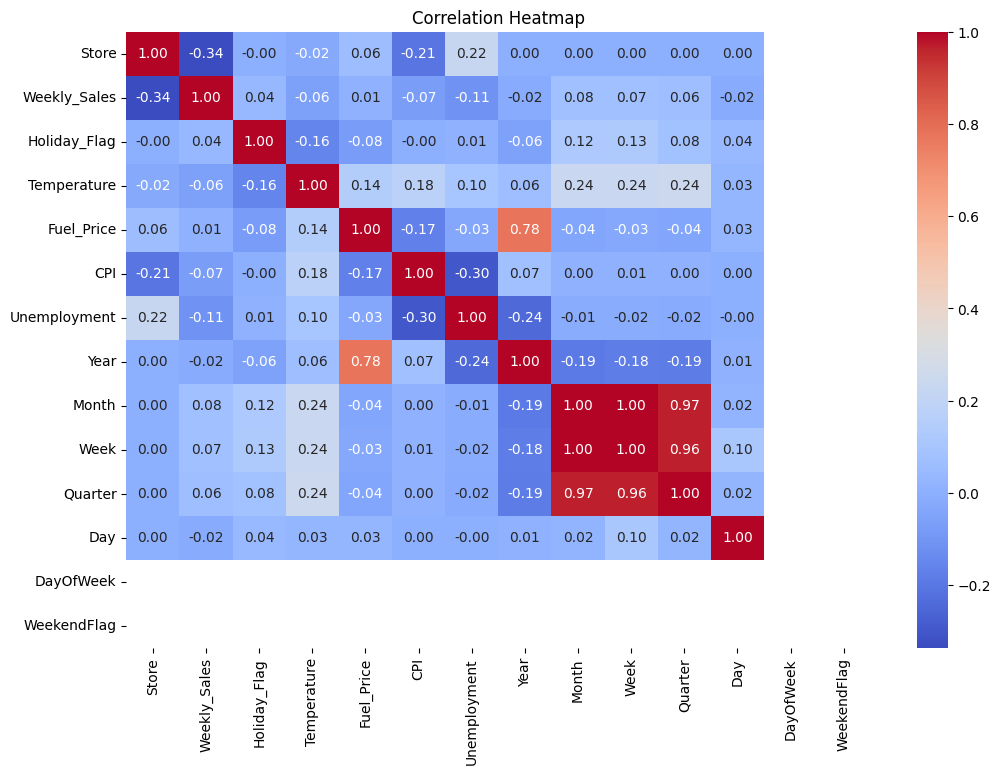

In [11]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Seasonal Decomposition

In [16]:
sales_series = df.groupby("Date")["Weekly_Sales"].sum()

sales_series = sales_series.sort_index()

sales_series = sales_series.interpolate()

print("Missing values:", sales_series.isna().sum())

Missing values: 0


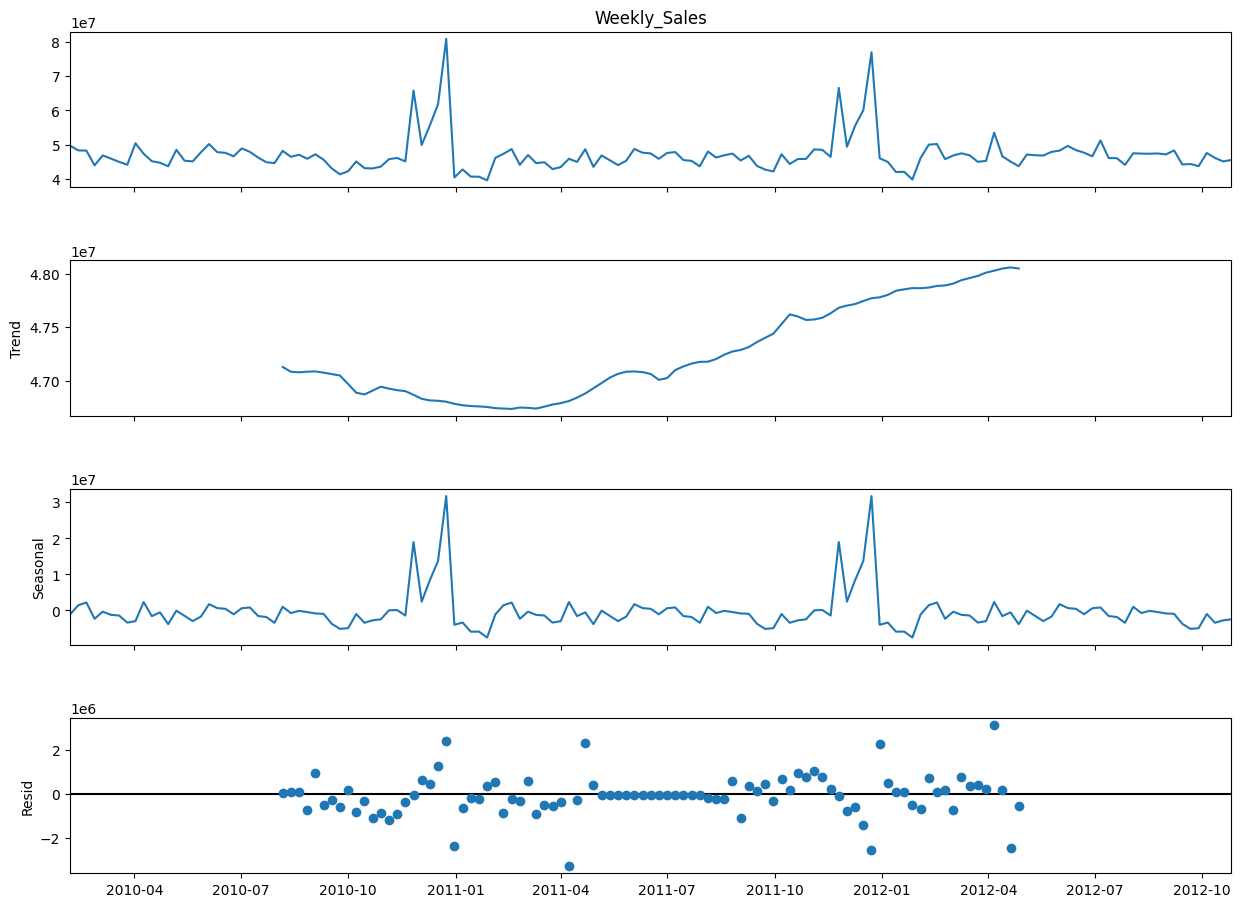

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    sales_series,
    model="additive",
    period=52
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

Sales Distribution

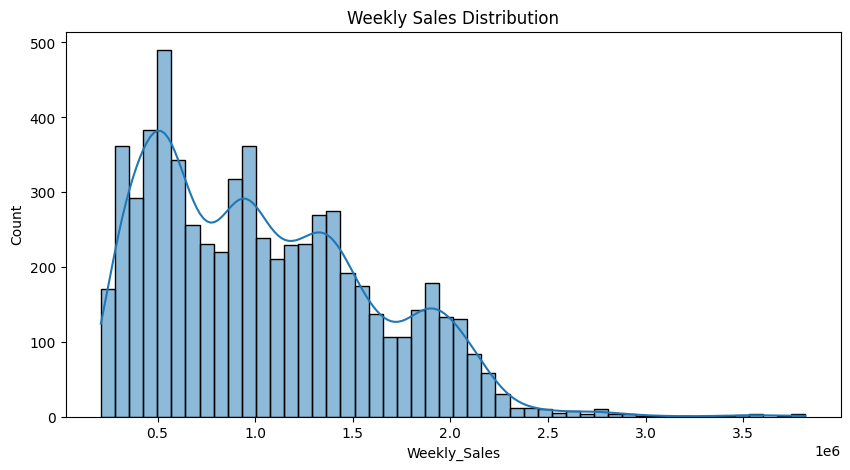

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Weekly_Sales"],
    bins=50,
    kde=True
)

plt.title("Weekly Sales Distribution")

plt.show()

Temperature vs Sales

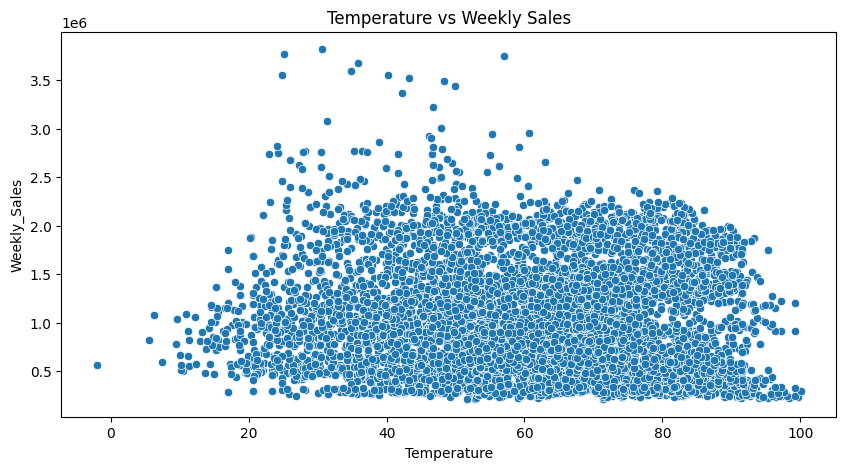

In [19]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="Temperature",
    y="Weekly_Sales"
)

plt.title("Temperature vs Weekly Sales")

plt.show()

Unemployment vs Sales

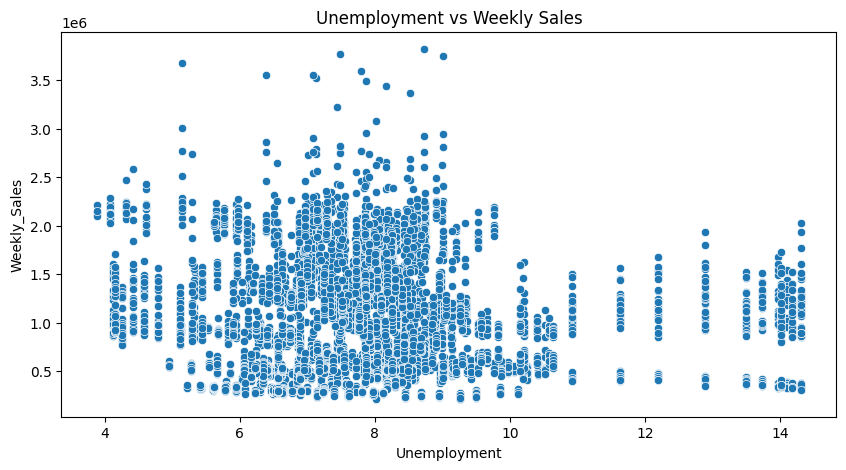

In [20]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="Unemployment",
    y="Weekly_Sales"
)

plt.title("Unemployment vs Weekly Sales")

plt.show()

Save Plots Folder

In [21]:
import os

os.makedirs("../outputs/plots", exist_ok=True)

print("Plots folder created successfully!")

Plots folder created successfully!
